# Machine Learning & Deep Learning — Full Course Companion Notebook

**Prepared for course revision, viva, and syllabus coverage**

This notebook is deliberately **separate from the Student Risk OULAD project notebook**.

## Source basis
This notebook follows:
1. `Machine_Learning_and_Deep_Learning_Topics(1).docx`
2. `Machine_Learning_and_Deep_Learning_Technical_Reference_Ahmed_Abogreer_Amira_Mostafa (1)(1).docx`
3. The supplied **38-topic Deep Learning list**.

### Source-integrity note
The supplied technical reference explains the ML workflow, supervised models, losses, evaluation, clustering, PCA, reinforcement learning, ANN foundations, activation functions, backpropagation/optimizers, and CNN foundations in detail.

Some advanced Deep Learning items in the 38-topic list (for example RNN/LSTM/GRU, Seq2Seq, Autoencoders, Transfer Learning, Word Embeddings, Transformers, Attention, GANs, and PyTorch) are **listed in the syllabus but not elaborated to the same depth in the supplied technical reference**. Those sections are marked **Supplementary standard implementation example** so the notebook does not pretend that extra detail came from the reference.

## How to use this notebook
- Use **Part A** for Machine Learning revision.
- Use **Part B** for the 38 Deep Learning topics.
- Use **Part C** for fast viva review.
- Code examples are intentionally small and offline-friendly.
- TensorFlow/Keras and PyTorch sections are guarded so the notebook remains runnable even if those packages are not installed.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import (
    make_classification, make_regression, make_blobs, load_digits, load_iris
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_validate, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, log_loss,
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score
)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, LogisticRegression, Perceptron
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, RandomForestRegressor
)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier, MLPRegressor

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

print("Core libraries loaded.")


Core libraries loaded.


# Part A — Machine Learning

The supplied course material frames Machine Learning as learning patterns from data and separates the main paradigms into:
- **Supervised Learning**
- **Unsupervised Learning**
- **Reinforcement Learning**

Deep Learning is a model family that can be used under more than one learning paradigm.


## A1. Introduction to Machine Learning

Machine Learning learns a mapping, structure, or decision rule from data instead of relying only on manually written rules.

A useful first question is:

**Do we have a target `y`?**
- Yes → Supervised Learning
- No → Unsupervised Learning
- Sequential actions + rewards → Reinforcement Learning


## A2. Supervised Learning

Supervised learning uses input features `X` and known targets `y`.

Two main supervised tasks:
- **Classification:** predict a category/class.
- **Regression:** predict a continuous numeric value.


### Classification dataset used in the teaching examples

In [2]:
X_num, y_cls = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    weights=[0.58, 0.42],
    class_sep=1.05,
    random_state=RANDOM_STATE
)

X_cls = pd.DataFrame(X_num, columns=[f"num_{i}" for i in range(6)])
X_cls["study_mode"] = np.where(X_cls["num_0"] > np.median(X_cls["num_0"]), "online", "blended")

# introduce missing values to demonstrate imputation
for col in ["num_2", "num_4", "study_mode"]:
    idx = rng.choice(len(X_cls), size=25, replace=False)
    X_cls.loc[idx, col] = np.nan

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, stratify=y_cls, random_state=RANDOM_STATE
)

numeric_cols = [c for c in X_cls.columns if c.startswith("num_")]
categorical_cols = ["study_mode"]

numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

prep_scaled = ColumnTransformer([
    ("num", numeric_scaled, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

prep_unscaled = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

print("Training rows:", len(X_train_cls))
print("Test rows:", len(X_test_cls))


Training rows: 800
Test rows: 200


## A3. Data Preprocessing

Typical preprocessing steps in the supplied reference:
- inspect data types and invalid values
- handle missing values
- encode categorical features
- scale where needed
- separate identifiers from predictive features
- avoid leakage by fitting preprocessing on training data only


### A3.1 Handling Missing Values

In [3]:
demo_missing = X_cls.isna().sum().sort_values(ascending=False)
demo_missing[demo_missing > 0].to_frame("missing_count")


,missing_count
num_2,25
study_mode,25
num_4,25


### A3.2 Encoding

In [4]:
encoder_demo = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded = encoder_demo.fit_transform(
    pd.DataFrame({"mode": ["online", "blended", "online"]})
)
pd.DataFrame(encoded, columns=encoder_demo.get_feature_names_out())


,mode_blended,mode_online
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0


### A3.3 Feature Scaling

In [5]:
values = np.array([[18, 1200], [35, 5000], [60, 200000]], dtype=float)
scaled = StandardScaler().fit_transform(values)
pd.DataFrame(
    np.c_[values, scaled],
    columns=["age", "salary", "age_scaled", "salary_scaled"]
).round(3)


,age,salary,age_scaled,salary_scaled
0,18.0,1200.0,-1.140,-0.727
1,35.0,5000.0,-0.155,-0.687
2,60.0,200000.0,1.295,1.414


## A4. Linear Regression

Linear Regression predicts a numeric target using a weighted sum of input features plus an intercept.

It is a natural regression baseline and is evaluated with regression metrics such as MSE, RMSE, MAE, and R².


In [6]:
X_reg, y_reg = make_regression(
    n_samples=800, n_features=8, n_informative=6,
    noise=18, random_state=RANDOM_STATE
)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

lin = LinearRegression().fit(X_train_reg, y_train_reg)
lin_pred = lin.predict(X_test_reg)

mse = mean_squared_error(y_test_reg, lin_pred)
pd.Series({
    "MSE": mse,
    "RMSE": np.sqrt(mse),
    "MAE": mean_absolute_error(y_test_reg, lin_pred),
    "R2": r2_score(y_test_reg, lin_pred)
}).round(4)


MSE     394.2730
RMSE     19.8563
MAE      15.3573
R2        0.9741
dtype: float64

## A5. Logistic Regression

Despite the name, Logistic Regression is primarily a **classification** algorithm.  
It maps a linear score through the sigmoid function to produce a class probability.


In [7]:
log_model = Pipeline([
    ("prep", prep_scaled),
    ("model", LogisticRegression(max_iter=1500, random_state=RANDOM_STATE))
])
log_model.fit(X_train_cls, y_train_cls)
log_prob = log_model.predict_proba(X_test_cls)[:, 1]
log_pred = log_model.predict(X_test_cls)

pd.Series({
    "Accuracy": accuracy_score(y_test_cls, log_pred),
    "Precision": precision_score(y_test_cls, log_pred),
    "Recall": recall_score(y_test_cls, log_pred),
    "F1": f1_score(y_test_cls, log_pred),
    "ROC_AUC": roc_auc_score(y_test_cls, log_prob),
    "Log_Loss": log_loss(y_test_cls, log_prob)
}).round(4)


Accuracy     0.6600
Precision    0.6000
Recall       0.5714
F1           0.5854
ROC_AUC      0.7694
Log_Loss     0.5623
dtype: float64

## A6. Naive Bayes

Naive Bayes is a probabilistic classifier based on Bayes' theorem and a conditional-independence assumption.

Common variants:
- Gaussian Naive Bayes
- Multinomial Naive Bayes
- Bernoulli Naive Bayes


## A7. K-Nearest Neighbors (KNN)

KNN is instance-based learning.
- Classification → neighbors vote for a class.
- Regression → neighbors' numeric targets are averaged.
- Scaling matters because the method relies on distance.


## A8. Support Vector Machines (SVM / SVR)

SVM classification searches for a separating boundary with a large margin.  
SVR adapts the margin idea to numeric prediction.

Important hyperparameters include `C`, `gamma`, kernel, and `epsilon` for SVR.


## A9. Decision Trees

A Decision Tree recursively splits the feature space using if/then rules.

- Classification trees reduce class impurity.
- Regression trees reduce numeric prediction error.
- Trees usually do not require feature scaling.
- Deep unrestricted trees can overfit.


## A10. Classification Model Comparison

In [8]:
classification_models = {
    "Logistic Regression": Pipeline([
        ("prep", prep_scaled),
        ("model", LogisticRegression(max_iter=1500, random_state=RANDOM_STATE))
    ]),
    "Naive Bayes": Pipeline([
        ("prep", prep_scaled),
        ("model", GaussianNB())
    ]),
    "KNN": Pipeline([
        ("prep", prep_scaled),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),
    "SVM": Pipeline([
        ("prep", prep_scaled),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
    ]),
    "Decision Tree": Pipeline([
        ("prep", prep_unscaled),
        ("model", DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("prep", prep_unscaled),
        ("model", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
    ]),
}

classification_rows = []
fitted_models = {}

for name, model in classification_models.items():
    model.fit(X_train_cls, y_train_cls)
    pred = model.predict(X_test_cls)
    prob = model.predict_proba(X_test_cls)[:, 1]
    fitted_models[name] = model
    classification_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_cls, pred),
        "Precision": precision_score(y_test_cls, pred),
        "Recall": recall_score(y_test_cls, pred),
        "F1": f1_score(y_test_cls, pred),
        "ROC-AUC": roc_auc_score(y_test_cls, prob),
        "Log Loss": log_loss(y_test_cls, prob),
    })

classification_results = pd.DataFrame(classification_rows).sort_values("F1", ascending=False)
classification_results.round(4)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Log Loss
2,KNN,0.935,0.9610,0.8810,0.9193,0.9723,0.5098
5,Random Forest,0.920,0.9146,0.8929,0.9036,0.9705,0.2314
3,SVM,0.920,0.9474,0.8571,0.9000,0.9667,0.2091
4,Decision Tree,0.890,0.8690,0.8690,0.8690,0.8971,1.4703
1,Naive Bayes,0.660,0.5816,0.6786,0.6264,0.7387,0.9655
0,Logistic Regression,0.660,0.6000,0.5714,0.5854,0.7694,0.5623


## A11. Confusion Matrix

,Predicted 0,Predicted 1
Actual 0,113,3
Actual 1,10,74


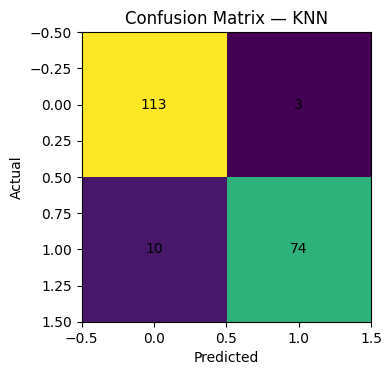

In [9]:
best_name = classification_results.iloc[0]["Model"]
best_model = fitted_models[best_name]
cm = confusion_matrix(y_test_cls, best_model.predict(X_test_cls))

display(pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"]))

plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


## A12. Model Evaluation

### Classification metrics
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- Confusion Matrix
- Log Loss / Cross-Entropy

### Regression metrics
- MSE
- RMSE
- MAE
- R²

Training loss and reporting metric do not have to be the same.


## A13. KNN, SVR, and Decision Tree Regression

In [10]:
regression_models = {
    "Linear Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "KNN Regressor": Pipeline([
        ("scale", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=7))
    ]),
    "SVR": Pipeline([
        ("scale", StandardScaler()),
        ("model", SVR(C=10, epsilon=0.1))
    ]),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=8, random_state=RANDOM_STATE
    )
}

reg_rows = []
for name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    pred = model.predict(X_test_reg)
    mse = mean_squared_error(y_test_reg, pred)
    reg_rows.append({
        "Model": name,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_test_reg, pred),
        "R2": r2_score(y_test_reg, pred)
    })

pd.DataFrame(reg_rows).sort_values("RMSE").round(4)


,Model,MSE,RMSE,MAE,R2
0,Linear Regression,394.2730,19.8563,15.3573,0.9741
3,Decision Tree Regressor,2766.4298,52.5969,39.9663,0.8180
1,KNN Regressor,2852.2729,53.4067,39.1675,0.8124
2,SVR,3493.8146,59.1085,35.4552,0.7701


## A14. Random Forest

Random Forest combines many decision trees.

Key idea:
- train multiple trees on randomized samples/features
- aggregate predictions
- reduce the instability of a single tree

It is an ensemble method.


## A15. Ensemble Learning

Ensemble Learning combines multiple models.

Examples:
- Voting
- Bagging
- Random Forest
- Boosting

The goal is often to improve robustness or predictive performance compared with a single model.


In [11]:
voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1500)),
        ("nb", GaussianNB()),
        ("tree", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
    ],
    voting="soft"
)

# Dense numeric-only teaching example for compactness
X_small, y_small = make_classification(
    n_samples=700, n_features=8, n_informative=5, random_state=RANDOM_STATE
)
Xtr, Xte, ytr, yte = train_test_split(
    X_small, y_small, test_size=0.2, stratify=y_small, random_state=RANDOM_STATE
)
voting.fit(Xtr, ytr)
print("Voting accuracy:", round(accuracy_score(yte, voting.predict(Xte)), 4))


Voting accuracy: 0.8786


## A16. Boosting

Boosting builds learners sequentially so later learners focus more on previous errors.

Examples:
- AdaBoost
- Gradient Boosting


In [12]:
boost_models = {
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}
for name, model in boost_models.items():
    model.fit(Xtr, ytr)
    print(name, "accuracy =", round(accuracy_score(yte, model.predict(Xte)), 4))


AdaBoost accuracy = 0.85


GradientBoosting accuracy = 0.8714


## A17. Unsupervised Learning

Unsupervised learning uses input `X` without known target labels.

Typical goals:
- clustering
- structure discovery
- density modeling
- dimensionality reduction


## A18. K-Means and K-Means++

In [13]:
X_blob, _ = make_blobs(
    n_samples=600, centers=4, cluster_std=0.9, random_state=RANDOM_STATE
)

km_random = KMeans(n_clusters=4, init="random", n_init=10, random_state=RANDOM_STATE)
km_plus = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=RANDOM_STATE)

lab_random = km_random.fit_predict(X_blob)
lab_plus = km_plus.fit_predict(X_blob)

pd.DataFrame([
    {
        "Method": "K-Means random init",
        "Inertia": km_random.inertia_,
        "Silhouette": silhouette_score(X_blob, lab_random)
    },
    {
        "Method": "K-Means++ init",
        "Inertia": km_plus.inertia_,
        "Silhouette": silhouette_score(X_blob, lab_plus)
    }
]).round(4)


,Method,Inertia,Silhouette
0,K-Means random init,941.8991,0.8093
1,K-Means++ init,941.8991,0.8093


K-Means++ is a smarter **initialization** strategy for K-Means; it is not a different clustering objective.


## A19. Hierarchical Clustering

In [14]:
hier = AgglomerativeClustering(n_clusters=4)
hier_labels = hier.fit_predict(X_blob)
print("Hierarchical silhouette:", round(silhouette_score(X_blob, hier_labels), 4))


Hierarchical silhouette: 0.8093


## A20. DBSCAN

In [15]:
db = DBSCAN(eps=0.55, min_samples=5)
db_labels = db.fit_predict(X_blob)
clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise = int(np.sum(db_labels == -1))
print("Clusters:", clusters)
print("Noise points:", noise)


Clusters: 5
Noise points: 38


## A21. Gaussian Mixture Model (GMM)

In [16]:
gmm = GaussianMixture(n_components=4, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_blob)
gmm_probs = gmm.predict_proba(X_blob[:5])
display(pd.DataFrame(gmm_probs).round(3))


,0,1,2,3
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0


GMM provides **soft probabilistic membership**, unlike K-Means' hard cluster assignment.


## A22. Principal Component Analysis (PCA)

Original dimensions: 64
Reduced dimensions: 2
Explained variance by first 2 PCs: 0.2159


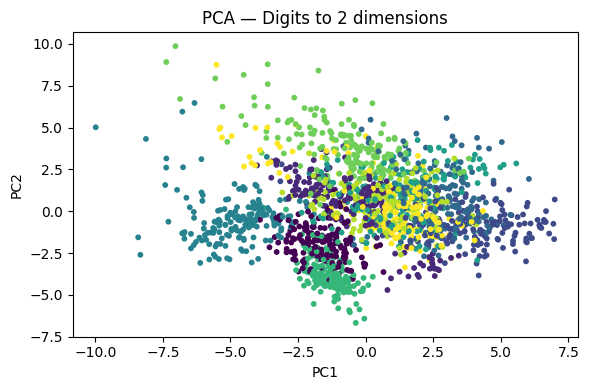

In [17]:
digits = load_digits()
X_digits = StandardScaler().fit_transform(digits.data)
pca = PCA(n_components=2)
X_digits_2d = pca.fit_transform(X_digits)

print("Original dimensions:", digits.data.shape[1])
print("Reduced dimensions:", X_digits_2d.shape[1])
print("Explained variance by first 2 PCs:", round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(6, 4))
plt.scatter(X_digits_2d[:, 0], X_digits_2d[:, 1], c=digits.target, s=10)
plt.title("PCA — Digits to 2 dimensions")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


## A23. Feature Selection

Feature selection keeps a subset of original features rather than creating new components.

This differs from PCA:
- Feature Selection → keeps original columns
- PCA → creates new component axes


In [18]:
X_fs, y_fs = make_classification(
    n_samples=500, n_features=12, n_informative=4, random_state=RANDOM_STATE
)
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X_fs, y_fs)
print("Original features:", X_fs.shape[1])
print("Selected features:", X_selected.shape[1])
print("Selected indices:", selector.get_support(indices=True).tolist())


Original features: 12
Selected features: 5
Selected indices: [3, 6, 7, 10, 11]


## A24. Handling Imbalanced Data

When classes are imbalanced:
- accuracy can be misleading
- inspect Precision, Recall, F1, ROC-AUC and often PR-AUC
- use stratified splitting
- consider class weighting, resampling, or threshold tuning when justified


## A25. Overfitting & Underfitting

In [19]:
X_ov, y_ov = make_classification(
    n_samples=500, n_features=12, n_informative=5, flip_y=0.12,
    random_state=RANDOM_STATE
)
Xtr_o, Xte_o, ytr_o, yte_o = train_test_split(
    X_ov, y_ov, test_size=0.3, stratify=y_ov, random_state=RANDOM_STATE
)

depth_rows = []
for depth in [1, 3, 6, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    tree.fit(Xtr_o, ytr_o)
    depth_rows.append({
        "max_depth": str(depth),
        "train_accuracy": accuracy_score(ytr_o, tree.predict(Xtr_o)),
        "test_accuracy": accuracy_score(yte_o, tree.predict(Xte_o))
    })

pd.DataFrame(depth_rows).round(4)


,max_depth,train_accuracy,test_accuracy
0,1,0.7343,0.7400
1,3,0.8800,0.8533
2,6,0.9714,0.8133
3,None,1.0000,0.8133


## A26. Regularization

Regularization discourages overly complex fitted behavior.

Examples:
- L1 / Lasso
- L2 / Ridge
- Logistic Regression regularization
- Weight decay in neural networks


In [20]:
reg_demo = pd.DataFrame({
    "x1": rng.normal(size=200),
    "x2": rng.normal(size=200),
})
reg_demo["y"] = 4*reg_demo["x1"] - 2*reg_demo["x2"] + rng.normal(scale=2, size=200)

Xr = reg_demo[["x1", "x2"]]
yr = reg_demo["y"]

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.2)
}
for name, m in models.items():
    m.fit(Xr, yr)
    print(name, "coefficients:", np.round(m.coef_, 3))


Linear coefficients: [ 3.881 -1.814]
Ridge coefficients: [ 3.679 -1.725]
Lasso coefficients: [ 3.659 -1.612]


## A27. Cross-Validation

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    LogisticRegression(max_iter=1500),
    X_small, y_small,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)
pd.Series({
    metric.replace("test_", ""): cv_scores[metric].mean()
    for metric in cv_scores if metric.startswith("test_")
}).round(4)


accuracy     0.7643
precision    0.7573
recall       0.7811
f1           0.7686
roc_auc      0.8328
dtype: float64

## A28. Hyperparameter Tuning

In [22]:
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={
        "n_neighbors": [3, 5, 7, 11],
        "weights": ["uniform", "distance"]
    },
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid.fit(Xtr, ytr)
print("Best params:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 4))


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 112, in start_daemon
RuntimeError: Failed to start artifact tool daemon (exited early)
Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/sprea

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 112, in start_daemon
RuntimeError: Failed to start artifact tool daemon (exited early)


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 112, in start_daemon
RuntimeError: Failed to start artifact tool daemon (exited early)


Best params: {'n_neighbors': 5, 'weights': 'uniform'}
Best CV F1: 0.9218


## A29. Reinforcement Learning

Reinforcement Learning uses:
- Agent
- Environment
- State
- Action
- Reward
- Policy
- Return

The goal is to learn actions that maximize expected cumulative reward.


In [23]:
# Minimal Q-learning example: 1-D world, goal at state 5.
n_states = 6
n_actions = 2  # 0=left, 1=right
goal = 5

Q = np.zeros((n_states, n_actions))
alpha = 0.2
gamma = 0.95
epsilon = 0.2
rng_rl = np.random.default_rng(RANDOM_STATE)

for episode in range(500):
    state = 0
    for _ in range(30):
        if rng_rl.random() < epsilon:
            action = int(rng_rl.integers(n_actions))
        else:
            action = int(np.argmax(Q[state]))

        next_state = max(0, state - 1) if action == 0 else min(goal, state + 1)
        reward = 10 if next_state == goal else -0.1

        Q[state, action] += alpha * (
            reward + gamma*np.max(Q[next_state]) - Q[state, action]
        )
        state = next_state
        if state == goal:
            break

display(pd.DataFrame(Q, columns=["Left", "Right"]).round(3))
print("Learned policy:", np.argmax(Q, axis=1).tolist())


,Left,Right
0,7.285,7.774
1,7.285,8.288
2,7.774,8.830
3,8.288,9.400
4,8.830,10.000
5,0.000,0.000


Learned policy: [1, 1, 1, 1, 1, 0]


# Part B — Deep Learning: 38 Topics

The headings below follow the supplied 38-topic Deep Learning list exactly.

Where the supplied technical reference contains detailed treatment, this notebook stays aligned with that terminology.  
Where a topic is only listed in the syllabus and not elaborated in the technical reference, the section is explicitly marked:

**Supplementary standard implementation example**


## DL 1. Introduction to Deep Learning

Deep Learning uses neural networks with multiple representation-learning layers.

Important distinction from the supplied reference:
- Deep Learning is not automatically “classification”.
- Neural networks can support classification, regression, representation learning, generative modeling, and reinforcement-learning tasks.


## DL 2. Artificial Neural Networks (ANN)

A feed-forward ANN commonly contains:
- input layer
- one or more hidden layers
- output layer

Each neuron computes a weighted sum plus bias, followed by an activation function.


## DL 3. Perceptron

In [24]:
# Classic perceptron on the AND truth table.
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0,0,0,1])

perceptron = Perceptron(max_iter=1000, random_state=RANDOM_STATE)
perceptron.fit(X_and, y_and)

pd.DataFrame({
    "x1": X_and[:,0],
    "x2": X_and[:,1],
    "target": y_and,
    "prediction": perceptron.predict(X_and)
})


,x1,x2,target,prediction
0,0,0,0,0
1,0,1,0,0
2,1,0,0,0
3,1,1,1,1


A perceptron is a single linear neuron/classifier. It can solve linearly separable problems but cannot represent every nonlinear pattern by itself.


## DL 4. Neural Network Architecture

Architecture describes:
- number of layers
- neurons/units per layer
- connectivity pattern
- activation functions
- output design

Example binary classifier:

`Input → Dense(32, ReLU) → Dense(16, ReLU) → Dense(1, Sigmoid)`


## DL 5. Forward Propagation

In [25]:
# Manual forward pass for a tiny 2-layer neural network.
x = np.array([[0.5, -1.0]])

W1 = np.array([[0.4, -0.2, 0.1],
               [0.3,  0.6, -0.5]])
b1 = np.array([0.1, 0.0, 0.2])

W2 = np.array([[0.7], [-0.4], [0.2]])
b2 = np.array([0.05])

relu = lambda z: np.maximum(0, z)
sigmoid = lambda z: 1 / (1 + np.exp(-z))

z1 = x @ W1 + b1
a1 = relu(z1)
z2 = a1 @ W2 + b2
y_hat = sigmoid(z2)

print("z1 =", np.round(z1, 3))
print("a1 =", np.round(a1, 3))
print("output probability =", np.round(y_hat, 4))


z1 = [[ 0.   -0.7   0.75]]
a1 = [[0.   0.   0.75]]
output probability = [[0.5498]]


Forward propagation moves information from input to output:
`input → weighted sums → activations → prediction`.


## DL 6. Backpropagation

In [26]:
# Tiny numerical gradient example: dL/dw by finite differences.
def sigmoid_scalar(z):
    return 1/(1+np.exp(-z))

def binary_ce(y, p):
    p = np.clip(p, 1e-8, 1-1e-8)
    return -(y*np.log(p) + (1-y)*np.log(1-p))

x_val, y_true, w, b = 2.0, 1.0, 0.3, 0.0

def loss_for_weight(w_value):
    p = sigmoid_scalar(w_value*x_val + b)
    return binary_ce(y_true, p)

eps = 1e-5
grad_numeric = (loss_for_weight(w+eps) - loss_for_weight(w-eps)) / (2*eps)

p = sigmoid_scalar(w*x_val+b)
grad_analytic = (p-y_true)*x_val

print("Numerical gradient:", round(float(grad_numeric), 6))
print("Analytic gradient :", round(float(grad_analytic), 6))


Numerical gradient: -0.708687
Analytic gradient : -0.708687


Backpropagation calculates gradients of the loss with respect to network parameters by applying the chain rule from output back through earlier layers.


## DL 7. Activation Functions

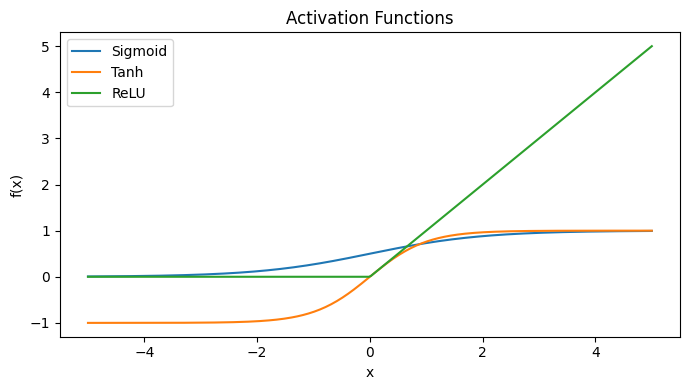

In [27]:
x_act = np.linspace(-5, 5, 300)
sigmoid_y = 1/(1+np.exp(-x_act))
tanh_y = np.tanh(x_act)
relu_y = np.maximum(0, x_act)

plt.figure(figsize=(7,4))
plt.plot(x_act, sigmoid_y, label="Sigmoid")
plt.plot(x_act, tanh_y, label="Tanh")
plt.plot(x_act, relu_y, label="ReLU")
plt.title("Activation Functions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()
plt.show()


Common activations in the supplied reference:
- ReLU → common hidden-layer activation
- Sigmoid → common binary output
- Tanh → some hidden/recurrent settings
- Softmax → multi-class output
- Linear → regression output


## DL 8. Loss Functions

In [28]:
y_true_demo = np.array([1, 0, 1, 1])
p_demo = np.array([0.9, 0.2, 0.7, 0.4])

binary_log_loss = log_loss(y_true_demo, p_demo)
mse_demo = mean_squared_error(
    np.array([3.0, 5.0, 7.0]),
    np.array([2.5, 5.4, 6.2])
)

print("Binary Log Loss:", round(binary_log_loss, 4))
print("Regression MSE:", round(mse_demo, 4))


Binary Log Loss: 0.4004
Regression MSE: 0.35


Typical pairings:
- binary classification → sigmoid + binary cross-entropy
- multi-class classification → softmax + categorical cross-entropy
- regression → linear output + MSE/MAE


## DL 9. Gradient Descent

In [29]:
# Gradient descent on f(w) = (w - 3)^2
w = -4.0
lr = 0.1
history = []

for step in range(25):
    loss = (w - 3)**2
    grad = 2*(w - 3)
    history.append((step, w, loss))
    w = w - lr*grad

pd.DataFrame(history, columns=["step","w","loss"]).head(10).round(4)


,step,w,loss
0,0,-4.0000,49.0000
1,1,-2.6000,31.3600
2,2,-1.4800,20.0704
3,3,-0.5840,12.8451
4,4,0.1328,8.2208
5,5,0.7062,5.2613
6,6,1.1650,3.3673
7,7,1.5320,2.1550
8,8,1.8256,1.3792
9,9,2.0605,0.8827


Gradient descent updates parameters in the negative-gradient direction:

`w_new = w_old - learning_rate × gradient`


## DL 10. Learning Rate

In [30]:
def run_gd(lr, steps=20):
    w = -4.0
    vals = []
    for i in range(steps):
        vals.append((i, w, (w-3)**2))
        w -= lr * 2*(w-3)
    return pd.DataFrame(vals, columns=["step","w","loss"])

lr_summary = pd.DataFrame({
    "learning_rate": [0.01, 0.1, 0.9],
    "final_loss": [
        run_gd(0.01).iloc[-1]["loss"],
        run_gd(0.1).iloc[-1]["loss"],
        run_gd(0.9).iloc[-1]["loss"],
    ]
})
lr_summary.round(6)


,learning_rate,final_loss
0,0.01,22.739817
1,0.10,0.010177
2,0.90,0.010177


Too small → slow learning.  
Too large → unstable updates or overshooting.  
A suitable learning rate balances speed and stability.


## DL 11. Batch, Mini-Batch & Stochastic Gradient Descent

In [31]:
n_samples = 1000
batch_sizes = {
    "Batch GD": n_samples,
    "Mini-Batch GD": 32,
    "Stochastic GD": 1
}

pd.DataFrame([
    {
        "Method": name,
        "Batch Size": size,
        "Updates per epoch": math.ceil(n_samples/size)
    }
    for name, size in batch_sizes.items()
])


,Method,Batch Size,Updates per epoch
0,Batch GD,1000,1
1,Mini-Batch GD,32,32
2,Stochastic GD,1,1000


- **Batch GD:** one update after processing the full training set.
- **Mini-Batch GD:** one update per subset/batch; common in modern DL.
- **SGD:** one sample per update.


## DL 12. Weight Initialization

In [32]:
fan_in = 100
fan_out = 50

standard = rng.normal(0, 1, size=(fan_in, fan_out))
xavier = rng.normal(0, np.sqrt(2/(fan_in+fan_out)), size=(fan_in, fan_out))
he = rng.normal(0, np.sqrt(2/fan_in), size=(fan_in, fan_out))

pd.DataFrame({
    "Initialization": ["Standard Normal", "Xavier-like", "He-like"],
    "Std": [standard.std(), xavier.std(), he.std()]
}).round(4)


,Initialization,Std
0,Standard Normal,1.0007
1,Xavier-like,0.1169
2,He-like,0.1412


Initialization affects signal and gradient stability.

Common ideas:
- Xavier/Glorot-style initialization
- He-style initialization for ReLU-like activations


## DL 13. Optimizers

The supplied reference describes:
- SGD
- Momentum
- RMSProp
- Adam
- AdamW

An optimizer uses gradients to update network parameters.  
Adam combines momentum-like first moments with adaptive second moments.


## DL 14. Overfitting & Underfitting

In [33]:
X_dl, y_dl = make_classification(
    n_samples=700, n_features=20, n_informative=6,
    flip_y=0.12, random_state=RANDOM_STATE
)
Xtr_dl, Xte_dl, ytr_dl, yte_dl = train_test_split(
    X_dl, y_dl, test_size=0.3, stratify=y_dl, random_state=RANDOM_STATE
)

rows = []
for hidden in [(2,), (20,), (100,100)]:
    m = Pipeline([
        ("scale", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=hidden, max_iter=500, random_state=RANDOM_STATE
        ))
    ])
    m.fit(Xtr_dl, ytr_dl)
    rows.append({
        "Architecture": str(hidden),
        "Train Accuracy": accuracy_score(ytr_dl, m.predict(Xtr_dl)),
        "Test Accuracy": accuracy_score(yte_dl, m.predict(Xte_dl))
    })

pd.DataFrame(rows).round(4)


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/generated/interface/models.py", line 32317, in hydrate_crdt_from_proto
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.

,Architecture,Train Accuracy,Test Accuracy
0,"(2,)",0.7653,0.7238
1,"(20,)",0.9449,0.7762
2,"(100, 100)",1.0000,0.7810


- Underfitting → poor training and poor validation/test performance.
- Overfitting → very strong training performance but noticeably worse unseen-data performance.


## DL 15. Regularization

Neural-network regularization methods include:
- L1/L2 penalties
- weight decay
- dropout
- early stopping
- data augmentation
- reducing model complexity


## DL 16. Dropout

Dropout randomly disables a fraction of activations during training.  
This prevents the network from relying too heavily on particular units and can reduce overfitting.

**Supplementary standard implementation example**
```python
keras.layers.Dropout(0.5)
```


## DL 17. Early Stopping

Early Stopping monitors validation performance and stops training when improvement stalls.

**Supplementary standard implementation example**
```python
keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
```


## DL 18. Batch Normalization

**Supplementary standard implementation example**

Batch Normalization normalizes intermediate activations using batch statistics during training and learns scale/shift parameters.

Typical layer:
```python
keras.layers.BatchNormalization()
```


## DL 19. Convolutional Neural Networks (CNN)

A CNN is designed for grid-like data such as images.

Typical flow from the supplied reference:

`Input Image → Convolution → Activation → Pooling/Downsampling → Deeper Conv Blocks → Feature Representation → Output Head`


## DL 20. Convolution & Filters

In [34]:
# Simple 2D convolution demonstration without external DL libraries.
image = np.array([
    [0,0,0,0,0],
    [0,1,1,1,0],
    [0,1,1,1,0],
    [0,1,1,1,0],
    [0,0,0,0,0]
], dtype=float)

vertical_edge_filter = np.array([
    [-1,0,1],
    [-1,0,1],
    [-1,0,1]
], dtype=float)

def conv2d_valid(img, kernel):
    kh, kw = kernel.shape
    oh, ow = img.shape[0]-kh+1, img.shape[1]-kw+1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            out[i,j] = np.sum(img[i:i+kh, j:j+kw] * kernel)
    return out

feature_map = conv2d_valid(image, vertical_edge_filter)
print("Input:")
display(pd.DataFrame(image))
print("Feature map:")
display(pd.DataFrame(feature_map))


Input:


,0,1,2,3,4
0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,1.0,1.0,0.0
2,0.0,1.0,1.0,1.0,0.0
3,0.0,1.0,1.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0


Feature map:


,0,1,2
0,2.0,0.0,-2.0
1,3.0,0.0,-3.0
2,2.0,0.0,-2.0


A filter/kernel slides across local image regions and computes weighted combinations. During training, filters are learned from data.


## DL 21. Pooling

In [35]:
feature = np.array([
    [1, 3, 2, 0],
    [4, 6, 5, 1],
    [0, 2, 8, 7],
    [1, 3, 9, 4]
], dtype=float)

def max_pool_2x2(x):
    out = np.zeros((x.shape[0]//2, x.shape[1]//2))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i,j] = np.max(x[i*2:i*2+2, j*2:j*2+2])
    return out

display(pd.DataFrame(feature))
print("2x2 Max pooled:")
display(pd.DataFrame(max_pool_2x2(feature)))


,0,1,2,3
0,1.0,3.0,2.0,0.0
1,4.0,6.0,5.0,1.0
2,0.0,2.0,8.0,7.0
3,1.0,3.0,9.0,4.0


2x2 Max pooled:


,0,1
0,6.0,5.0
1,3.0,9.0


## DL 22. CNN Architecture

A common CNN architecture:

`Image → Conv → ReLU → Pool → Conv → ReLU → Pool → Flatten/Global Pool → Dense → Output`

Different architectures vary in depth, residual connections, filter widths, normalization, and output heads.


## DL 23. Image Classification

In [36]:
# Offline image-classification baseline on sklearn's digits dataset.
X_img = digits.data / 16.0
y_img = digits.target

Xtr_img, Xte_img, ytr_img, yte_img = train_test_split(
    X_img, y_img, test_size=0.2, stratify=y_img, random_state=RANDOM_STATE
)

img_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=400,
    random_state=RANDOM_STATE
)
img_mlp.fit(Xtr_img, ytr_img)

print("Dense ANN digits accuracy:",
      round(accuracy_score(yte_img, img_mlp.predict(Xte_img)), 4))


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/generated/interface/models.py", line 32317, in hydrate_crdt_from_proto
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.

Dense ANN digits accuracy: 0.9778


The cell above is a dense-ANN image baseline.  
The CNN example later shows how spatial convolutions are represented in TensorFlow/Keras when available.


## DL 24. Recurrent Neural Networks (RNN)

**Supplementary standard implementation example**

RNNs process sequences step-by-step while carrying a hidden state.

Conceptual recurrence:
`h_t = f(W_x x_t + W_h h_(t-1) + b)`

They are designed for sequential data such as time series, text, and ordered signals.


In [37]:
# Tiny NumPy RNN forward pass.
sequence = np.array([[1.0], [0.5], [-0.2]])
Wx = np.array([[0.8]])
Wh = np.array([[0.4]])
b = np.array([0.0])

h = np.array([0.0])
states = []
for xt in sequence:
    h = np.tanh(Wx @ xt + Wh @ h + b)
    states.append(float(h[0]))

print("Hidden states:", np.round(states, 4))


Hidden states: [0.664  0.5821 0.0727]


## DL 25. Long Short-Term Memory (LSTM)

**Supplementary standard implementation example**

LSTM is a gated recurrent architecture designed to preserve and control information over longer sequences.

Key gates commonly described:
- forget gate
- input gate
- output gate
- cell state


## DL 26. Gated Recurrent Unit (GRU)

**Supplementary standard implementation example**

GRU is another gated recurrent architecture.  
It uses a more compact gating structure than LSTM, commonly including:
- update gate
- reset gate


## DL 27. Sequence-to-Sequence Models

**Supplementary standard implementation example**

Seq2Seq models map one sequence to another.

Classic structure:
`Encoder → context representation → Decoder`

Examples include translation, summarization, and sequence transformation.


## DL 28. Autoencoders

**Supplementary standard implementation example**

An autoencoder learns to reconstruct its input:

`Input → Encoder → Latent Representation → Decoder → Reconstruction`

Uses include:
- representation learning
- compression
- denoising
- anomaly-oriented reconstruction analysis


In [38]:
# Small PCA-like reconstruction analogy using PCA as an offline proxy
# for the encode/decode idea.
pca_auto = PCA(n_components=20)
Z = pca_auto.fit_transform(X_img)
X_recon = pca_auto.inverse_transform(Z)

print("Original dimension:", X_img.shape[1])
print("Latent dimension:", Z.shape[1])
print("Reconstruction MSE:", round(mean_squared_error(X_img, X_recon), 6))


Original dimension: 64
Latent dimension: 20
Reconstruction MSE: 0.007751


## DL 29. Transfer Learning

**Supplementary standard implementation example**

Transfer Learning reuses representations learned by a model trained on another task or dataset.

Typical image workflow:
1. load a pretrained backbone
2. freeze some/all backbone layers
3. add a task-specific head
4. train the new head
5. optionally fine-tune part of the backbone

A real pretrained-weight demo may require cached weights or internet access, so this notebook keeps the concept offline-safe.


## DL 30. Data Augmentation

In [39]:
# Simple image augmentation using an 8x8 digit image.
sample_img = digits.images[0]
augmented = {
    "original": sample_img,
    "horizontal_flip": np.fliplr(sample_img),
    "vertical_flip": np.flipud(sample_img),
    "rot90": np.rot90(sample_img)
}
print("Created augmentations:", list(augmented))


Created augmentations: ['original', 'horizontal_flip', 'vertical_flip', 'rot90']


Data augmentation creates transformed training examples to improve robustness.  
For real vision tasks, augmentations should preserve the label semantics.


## DL 31. Word Embeddings

**Supplementary standard implementation example**

Word embeddings map discrete tokens to dense numeric vectors.

Instead of representing each word as a huge one-hot vector, an embedding lookup returns a learned low-dimensional vector.


In [40]:
vocab = {"student":0, "risk":1, "model":2, "learning":3}
embedding_matrix = rng.normal(size=(len(vocab), 4))

tokens = ["student", "risk", "learning"]
vectors = np.vstack([embedding_matrix[vocab[t]] for t in tokens])

pd.DataFrame(vectors, index=tokens,
             columns=["e1","e2","e3","e4"]).round(3)


,e1,e2,e3,e4
student,-1.208,1.267,-1.008,0.746
risk,0.416,0.918,-0.515,-0.791
learning,-0.791,-0.994,-0.242,1.253


## DL 32. Transformers

**Supplementary standard implementation example**

Transformers process sequences using attention mechanisms rather than relying only on recurrent state propagation.

Typical encoder block:
`Input Embeddings → Self-Attention → Add/Norm → Feed-Forward → Add/Norm`

Transformers can model relationships between distant sequence positions efficiently.


## DL 33. Attention Mechanism

In [41]:
# Scaled dot-product attention demonstration.
Q = np.array([[1., 0.], [0., 1.]])
K = np.array([[1., 0.], [0.5, 0.5], [0., 1.]])
V = np.array([[10., 0.], [5., 5.], [0., 10.]])

scores = Q @ K.T / np.sqrt(K.shape[1])

def softmax(a, axis=-1):
    e = np.exp(a - np.max(a, axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

weights = softmax(scores, axis=1)
attention_output = weights @ V

print("Attention weights:")
display(pd.DataFrame(weights).round(3))
print("Attention output:")
display(pd.DataFrame(attention_output).round(3))


Attention weights:


,0,1,2
0,0.456,0.32,0.225
1,0.225,0.32,0.456


Attention output:


,0,1
0,6.155,3.845
1,3.845,6.155


Attention computes weighted combinations of value vectors using relevance scores between queries and keys.


## DL 34. Generative Adversarial Networks (GANs)

**Supplementary standard implementation example**

A GAN contains two competing networks:
- **Generator:** produces synthetic samples.
- **Discriminator:** tries to distinguish real from generated samples.

Training alternates between improving the discriminator and improving the generator so generated samples become harder to distinguish from real data.


## DL 35. Deep Learning Model Evaluation

Deep Learning evaluation still depends on the task.

### Classification
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC where appropriate
- Confusion Matrix
- cross-entropy / log loss

### Regression
- MSE
- RMSE
- MAE
- R²

Also inspect:
- training vs validation loss
- training vs validation metrics
- generalization gap
- calibration or class-specific performance when relevant


## DL 36. Hyperparameter Tuning

Common Deep Learning hyperparameters:
- learning rate
- batch size
- number of layers
- units/filters per layer
- dropout rate
- optimizer
- weight decay / regularization
- number of epochs
- activation functions

Tuning should use validation data or cross-validation-like development procedures, not the final test set.


## DL 37. TensorFlow & Keras

In [42]:
try:
    import tensorflow as tf
    from tensorflow import keras

    tf.random.set_seed(RANDOM_STATE)

    tf_model = keras.Sequential([
        keras.layers.Input(shape=(64,)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(10, activation="softmax")
    ])

    tf_model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print("TensorFlow version:", tf.__version__)
    tf_model.summary()

except Exception as exc:
    print("TensorFlow/Keras optional example skipped:", type(exc).__name__, str(exc)[:120])


TensorFlow/Keras optional example skipped: ModuleNotFoundError No module named 'tensorflow'


### TensorFlow/Keras CNN example

In [43]:
try:
    import tensorflow as tf
    from tensorflow import keras

    X_cnn = (digits.images.astype("float32") / 16.0)[..., np.newaxis]
    y_cnn = digits.target

    Xtr_cnn, Xte_cnn, ytr_cnn, yte_cnn = train_test_split(
        X_cnn, y_cnn, test_size=0.2, stratify=y_cnn, random_state=RANDOM_STATE
    )

    cnn = keras.Sequential([
        keras.layers.Input(shape=(8,8,1)),
        keras.layers.Conv2D(8, 3, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
        keras.layers.Flatten(),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(10, activation="softmax")
    ])

    cnn.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    cnn.fit(Xtr_cnn, ytr_cnn, epochs=2, batch_size=32, verbose=0)
    loss, acc = cnn.evaluate(Xte_cnn, yte_cnn, verbose=0)
    print("CNN accuracy:", round(float(acc), 4))

except Exception as exc:
    print("TensorFlow/Keras CNN optional example skipped:", type(exc).__name__, str(exc)[:120])


TensorFlow/Keras CNN optional example skipped: ModuleNotFoundError No module named 'tensorflow'


## DL 38. PyTorch

In [44]:
try:
    import torch
    import torch.nn as nn

    class TinyNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(6, 16),
                nn.ReLU(),
                nn.Linear(16, 2)
            )

        def forward(self, x):
            return self.net(x)

    torch_model = TinyNet()
    sample = torch.randn(4, 6)
    output = torch_model(sample)

    print("PyTorch version:", torch.__version__)
    print(torch_model)
    print("Sample output shape:", tuple(output.shape))

except Exception as exc:
    print("PyTorch optional example skipped:", type(exc).__name__, str(exc)[:120])


PyTorch version: 2.10.0+cpu
TinyNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)
Sample output shape: (4, 2)


# Part C — Exact Deep Learning Coverage Checklist

| # | Deep Learning Topic | Covered |
|---:|---|:---:|
| 1 | Introduction to Deep Learning | ✅ |
| 2 | Artificial Neural Networks (ANN) | ✅ |
| 3 | Perceptron | ✅ |
| 4 | Neural Network Architecture | ✅ |
| 5 | Forward Propagation | ✅ |
| 6 | Backpropagation | ✅ |
| 7 | Activation Functions | ✅ |
| 8 | Loss Functions | ✅ |
| 9 | Gradient Descent | ✅ |
| 10 | Learning Rate | ✅ |
| 11 | Batch, Mini-Batch & Stochastic Gradient Descent | ✅ |
| 12 | Weight Initialization | ✅ |
| 13 | Optimizers | ✅ |
| 14 | Overfitting & Underfitting | ✅ |
| 15 | Regularization | ✅ |
| 16 | Dropout | ✅ |
| 17 | Early Stopping | ✅ |
| 18 | Batch Normalization | ✅ |
| 19 | Convolutional Neural Networks (CNN) | ✅ |
| 20 | Convolution & Filters | ✅ |
| 21 | Pooling | ✅ |
| 22 | CNN Architecture | ✅ |
| 23 | Image Classification | ✅ |
| 24 | Recurrent Neural Networks (RNN) | ✅ |
| 25 | Long Short-Term Memory (LSTM) | ✅ |
| 26 | Gated Recurrent Unit (GRU) | ✅ |
| 27 | Sequence-to-Sequence Models | ✅ |
| 28 | Autoencoders | ✅ |
| 29 | Transfer Learning | ✅ |
| 30 | Data Augmentation | ✅ |
| 31 | Word Embeddings | ✅ |
| 32 | Transformers | ✅ |
| 33 | Attention Mechanism | ✅ |
| 34 | Generative Adversarial Networks (GANs) | ✅ |
| 35 | Deep Learning Model Evaluation | ✅ |
| 36 | Hyperparameter Tuning | ✅ |
| 37 | TensorFlow & Keras | ✅ |
| 38 | PyTorch | ✅ |

**Important:** ✅ means the topic is represented in this companion notebook.  
Some advanced topics are syllabus-listed but were not developed in depth in the supplied technical reference; those sections are explicitly labeled **Supplementary standard implementation example**.


# Part D — Viva Quick Review

## Machine Learning
- **Classification:** predicts classes/categories.
- **Regression:** predicts continuous numeric values.
- **Clustering:** discovers groups without target labels.
- **PCA:** reduces dimensions by projecting onto variance-maximizing components.
- **Cross-validation:** evaluates stability across multiple train/validation folds.
- **Hyperparameter tuning:** searches configuration choices such as K, C, depth, learning rate, etc.
- **Loss vs metric:** loss is the optimization objective; metric is a human-facing evaluation measure.

## Deep Learning
- **Perceptron:** single linear neuron/classifier.
- **ANN:** connected neural layers.
- **Forward pass:** compute prediction.
- **Backpropagation:** compute gradients.
- **Optimizer:** update parameters using gradients.
- **Learning rate:** controls update step size.
- **Dropout / Regularization / Early Stopping:** tools to reduce overfitting.
- **CNN:** neural architecture specialized for spatial/grid structure.
- **RNN/LSTM/GRU:** recurrent sequence architectures.
- **Seq2Seq:** maps an input sequence to an output sequence.
- **Autoencoder:** encoder + latent representation + decoder reconstruction.
- **Transfer Learning:** reuse previously learned representations.
- **Embedding:** dense vector representation of discrete tokens.
- **Attention:** weighted combination based on relevance.
- **Transformer:** attention-centric sequence architecture.
- **GAN:** generator competes with discriminator.
- **TensorFlow/Keras and PyTorch:** deep-learning frameworks.
